In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [182]:
mel_data = (
    pd.read_excel('Melbourne01.xlsx')
    .rename(columns=lambda col: col.strip())
)
mel_data.head()

,Year,Month,Day,Hour,Min,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),gamma,Calculated Dew Pt Temp (degrees C),E (hPa),Calculated Apparent Temp (degrees C)
0,2011,1,1.0,0.0,4.0,24.8,0.0,14.0,51.0,SE,11,13.0,1007.4,0,0.969609,14.1,15.916676,23.9
1,2011,1,1.0,0.0,14.0,24.8,0.0,13.3,48.0,SE,11,11.0,1007.5,0,0.908985,13.2,14.980401,23.6
2,2011,1,1.0,0.0,24.0,24.9,0.0,13.3,48.0,SE,11,13.0,1007.5,0,0.915025,13.2,15.069879,23.7
3,2011,1,1.0,0.0,34.0,24.7,0.0,13.4,49.0,SE,11,11.0,1007.4,0,0.923560,13.4,15.201624,23.6
4,2011,1,1.0,0.0,44.0,24.1,0.0,13.3,51.0,ESE,9,9.0,1007.3,0,0.927209,13.4,15.264860,23.4


# Data Cleaning and Preprocessing

In [ ]:
#Except for "Wind Direction", all columns should be numeric. Convert them to numeric types, coercing errors to NaN.

numeric_cols = mel_data.columns.drop("Wind Direction")

mel_data[numeric_cols] = mel_data[numeric_cols].apply(
    pd.to_numeric, errors='coerce'
)

mel_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505355 entries, 0 to 505354
Data columns (total 18 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Year                                  504606 non-null  float64
 1   Month                                 504723 non-null  float64
 2   Day                                   504723 non-null  float64
 3   Hour                                  504723 non-null  float64
 4   Min                                   504723 non-null  float64
 5   Air Temp (degrees C)                  504723 non-null  float64
 6   Apparent Temp (degrees C)             504723 non-null  float64
 7   Dew Pt Temp (degrees C)               504723 non-null  float64
 8   Humidity (%)                          504723 non-null  float64
 9   Wind Direction                        504723 non-null  object 
 10  Wind Speed (km/h)                     504590 non-null  float64
 11  

In [ ]:
# Calculate the percentage of missing values in the dataset (validation of NaN dropping)

(len(mel_data)-len(mel_data.dropna()))/len(mel_data)

0.0016918799655687585

In [185]:
mel_data = mel_data.dropna()
mel_data

,Year,Month,Day,Hour,Min,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),gamma,Calculated Dew Pt Temp (degrees C),E (hPa),Calculated Apparent Temp (degrees C)
0,2011.0,1.0,1.0,0.0,4.0,24.8,0.0,14.0,51.0,SE,11.0,13.0,1007.4,0.0,0.969609,14.1,15.916676,23.9
1,2011.0,1.0,1.0,0.0,14.0,24.8,0.0,13.3,48.0,SE,11.0,11.0,1007.5,0.0,0.908985,13.2,14.980401,23.6
2,2011.0,1.0,1.0,0.0,24.0,24.9,0.0,13.3,48.0,SE,11.0,13.0,1007.5,0.0,0.915025,13.2,15.069879,23.7
3,2011.0,1.0,1.0,0.0,34.0,24.7,0.0,13.4,49.0,SE,11.0,11.0,1007.4,0.0,0.923560,13.4,15.201624,23.6
4,2011.0,1.0,1.0,0.0,44.0,24.1,0.0,13.3,51.0,ESE,9.0,9.0,1007.3,0.0,0.927209,13.4,15.264860,23.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
505350,2022.0,3.0,8.0,15.0,40.0,18.6,16.0,13.2,71.0,SSW,39.0,46.0,1018.0,0.0,0.917431,13.3,15.179146,12.0
505351,2022.0,3.0,8.0,15.0,50.0,18.7,18.5,13.6,72.0,SSW,35.0,46.0,1017.9,0.0,0.937732,13.6,15.489394,13.0
505352,2022.0,3.0,8.0,16.0,0.0,18.9,17.6,13.7,72.0,SSW,35.0,41.0,1017.8,0.0,0.950348,13.8,15.683896,13.3
505353,2022.0,3.0,8.0,16.0,10.0,19.2,18.3,13.8,71.0,S,32.0,35.0,1017.8,0.0,0.955250,13.9,15.757716,14.2


In [189]:
# Datetime converting

mel_data.rename(columns={'Min': 'Minute'}, inplace=True)

mel_data['Datetime'] = pd.to_datetime(
    mel_data[['Year','Month','Day','Hour','Minute']]
)
mel_data.sort_values('Datetime', inplace=True)
mel_data.drop(columns=['Year','Month','Day','Hour','Minute'], inplace=True)
mel_data

,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),gamma,Calculated Dew Pt Temp (degrees C),E (hPa),Calculated Apparent Temp (degrees C),Datetime
0,24.8,0.0,14.0,51.0,SE,11.0,13.0,1007.4,0.0,0.969609,14.1,15.916676,23.9,2011-01-01 00:04:00
1,24.8,0.0,13.3,48.0,SE,11.0,11.0,1007.5,0.0,0.908985,13.2,14.980401,23.6,2011-01-01 00:14:00
2,24.9,0.0,13.3,48.0,SE,11.0,13.0,1007.5,0.0,0.915025,13.2,15.069879,23.7,2011-01-01 00:24:00
3,24.7,0.0,13.4,49.0,SE,11.0,11.0,1007.4,0.0,0.923560,13.4,15.201624,23.6,2011-01-01 00:34:00
4,24.1,0.0,13.3,51.0,ESE,9.0,9.0,1007.3,0.0,0.927209,13.4,15.264860,23.4,2011-01-01 00:44:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
505350,18.6,16.0,13.2,71.0,SSW,39.0,46.0,1018.0,0.0,0.917431,13.3,15.179146,12.0,2022-03-08 15:40:00
505351,18.7,18.5,13.6,72.0,SSW,35.0,46.0,1017.9,0.0,0.937732,13.6,15.489394,13.0,2022-03-08 15:50:00
505352,18.9,17.6,13.7,72.0,SSW,35.0,41.0,1017.8,0.0,0.950348,13.8,15.683896,13.3,2022-03-08 16:00:00
505353,19.2,18.3,13.8,71.0,S,32.0,35.0,1017.8,0.0,0.955250,13.9,15.757716,14.2,2022-03-08 16:10:00


In [190]:
mel_data.columns

Index(['Air Temp (degrees C)', 'Apparent Temp (degrees C)',
       'Dew Pt Temp (degrees C)', 'Humidity (%)', 'Wind Direction',
       'Wind Speed (km/h)', 'Wind Gust  (km/h)', 'MSLP (hPa)',
       'Rainfall since 9 am (mm)', 'gamma',
       'Calculated Dew Pt Temp (degrees C)', 'E (hPa)',
       'Calculated Apparent Temp (degrees C)', 'Datetime'],
      dtype='object')

In [191]:
# For continuous columns, identify outliers using the 2.5th and 97.5th percentiles (fixed quantile trimming).
# Interpolate with the average of their immediate neighbors (interpolation).

continuous_cols = [
    'Air Temp (degrees C)',
    'Apparent Temp (degrees C)',
    'Dew Pt Temp (degrees C)',
    'Humidity (%)',
    'Wind Speed (km/h)',
    'MSLP (hPa)',
    'E (hPa)',
    'gamma',
    'Calculated Dew Pt Temp (degrees C)',
    'Calculated Apparent Temp (degrees C)'
]

for col in continuous_cols:
    lower = mel_data[col].quantile(0.025)
    upper = mel_data[col].quantile(0.975)

    outlier = (mel_data[col] < lower) | (mel_data[col] > upper)

    mel_data.loc[outlier, col] = (mel_data[col].shift(1) + mel_data[col].shift(-1)) / 2

In [ ]:
# Visually check discontinuous columns

discontinuous_cols = mel_data.columns.difference(continuous_cols)
discontinuous_cols

Index(['Datetime', 'Rainfall since 9 am (mm)', 'Wind Direction',
       'Wind Gust  (km/h)'],
      dtype='object')

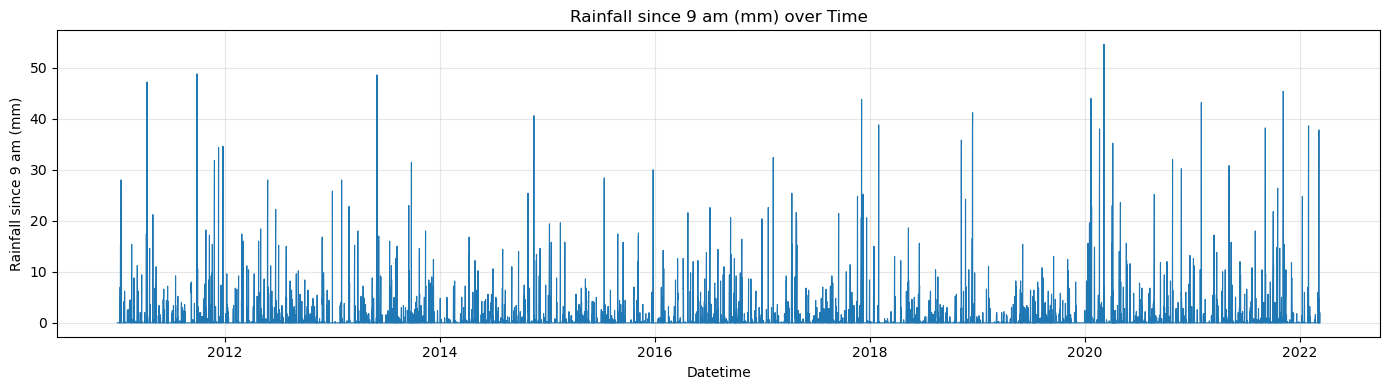

In [ ]:
# Valid rainfall data should be non-negative. Check for negative values in the "Rainfall since 9 am (mm)" column and handle them if necessary.

plt.figure(figsize=(14, 4))
plt.plot(mel_data['Datetime'], mel_data['Rainfall since 9 am (mm)'], linewidth=0.8)
plt.title('Rainfall since 9 am (mm) over Time')
plt.xlabel('Datetime')
plt.ylabel('Rainfall since 9 am (mm)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

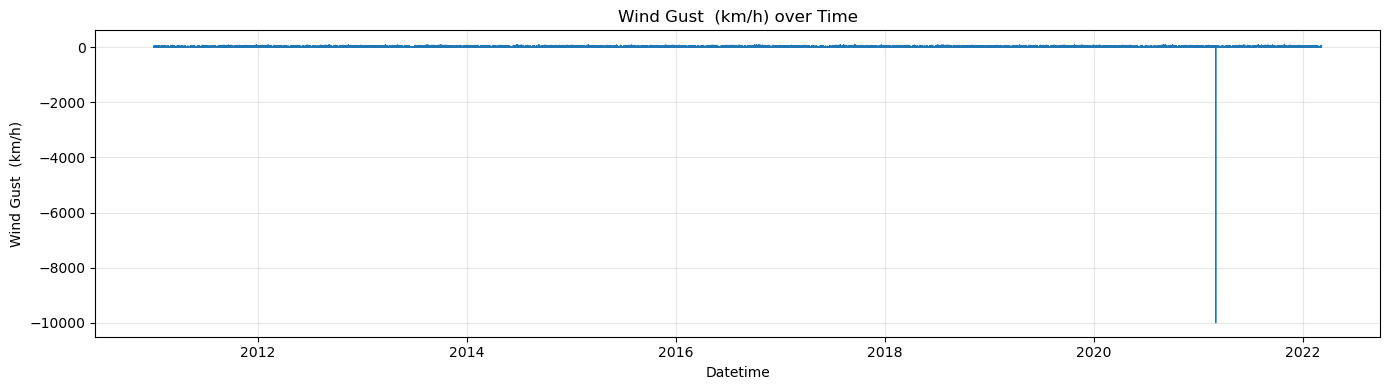

In [ ]:
# Valid wind gust data should be non-negative. Check for negative values in the "Wind Gust  (km/h)" column and handle them if necessary.

plt.figure(figsize=(14, 4))
plt.plot(mel_data['Datetime'], mel_data['Wind Gust  (km/h)'], linewidth=0.8)
plt.title('Wind Gust  (km/h) over Time')
plt.xlabel('Datetime')
plt.ylabel('Wind Gust  (km/h)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [198]:
len([mel_data['Wind Gust  (km/h)'] < 0])

1

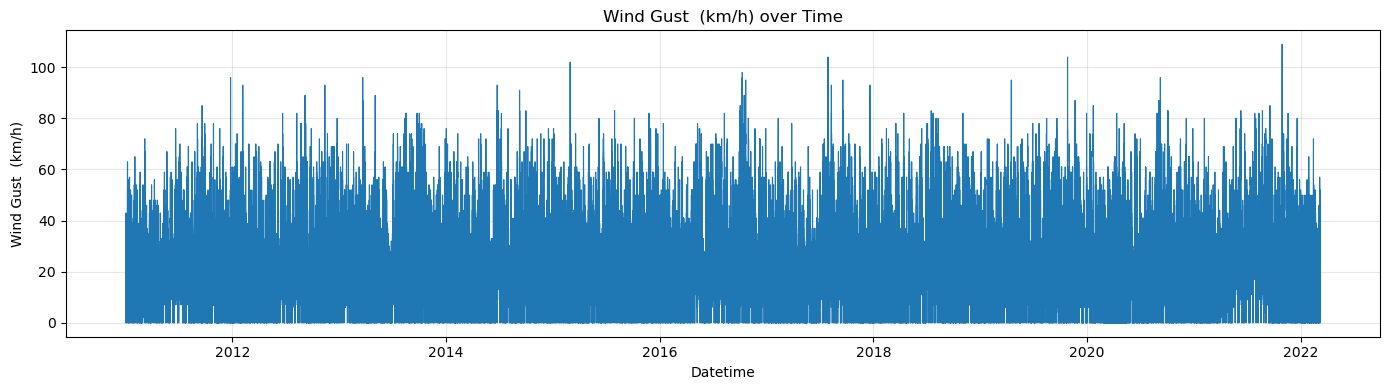

In [ ]:
mel_data = mel_data[mel_data['Wind Gust  (km/h)'] >= 0]

plt.figure(figsize=(14, 4))
plt.plot(mel_data['Datetime'], mel_data['Wind Gust  (km/h)'], linewidth=0.8)
plt.title('Wind Gust  (km/h) over Time')
plt.xlabel('Datetime')
plt.ylabel('Wind Gust  (km/h)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Valid wind direction data should not be numeric values. Check for unique values in the "Wind Direction" column to identify any invalid entries.

mel_data['Wind Direction'].unique()

array(['SE', 'ESE', 'NE', 'NNE', 'ENE', 'W', 'N', 'SW', 'SSE', 'S', 'SSW',
       'WSW', 'NW', 'WNW', 'NNW', 'E', 'CALM', 1016.6, 1016.9, 1017,
       1017.4, 1026, 1026.1, 1025.3, 1024.2, 1029.6, 1003.3, 1008.2, 1019,
       1015.5, 1014.2, 1015.9, 1016.2, 1016.1, 1014.1, 1014, 1013.6,
       1012.7, 1013.1, 1014.4, 1014.6, 1015.6, 1015.8, 1016.7, 1017.2,
       1016, 1017.8, 1019.5, 1019.8, 1019.9, 1020.4, 1021, 1021.2, 1021.7,
       1021.9, 1022.3, 1022.7, 1004.5, 1022, 1010.3, 1012, 1010.8],
      dtype=object)

In [203]:
valid_dr = ['SE', 'ESE', 'NE', 'NNE', 'ENE', 'W', 'N', 'SW', 'SSE', 'S', 'SSW', 'WSW', 'NW', 'WNW', 'NNW', 'E', 'CALM']
len(mel_data[~mel_data['Wind Direction'].isin(valid_dr)])

56

In [205]:
mel_data = mel_data[mel_data['Wind Direction'].isin(valid_dr)]
mel_data['Wind Direction'].unique()

array(['SE', 'ESE', 'NE', 'NNE', 'ENE', 'W', 'N', 'SW', 'SSE', 'S', 'SSW',
       'WSW', 'NW', 'WNW', 'NNW', 'E', 'CALM'], dtype=object)

In [209]:
# One-hot encode the "Wind Direction" column and drop the original column.
# Even though circular encoding using sine and cosine can capture geometric relationships, 
# one-hot encoding is more interpretable for tree-based models and can still capture the necessary information without introducing complexity.

dummies=pd.get_dummies(mel_data['Wind Direction'], prefix='WindDir')
mel_data_oh = mel_data.join(dummies).drop(columns=['Wind Direction'])

mel_data_oh

,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),gamma,Calculated Dew Pt Temp (degrees C),...,WindDir_NNW,WindDir_NW,WindDir_S,WindDir_SE,WindDir_SSE,WindDir_SSW,WindDir_SW,WindDir_W,WindDir_WNW,WindDir_WSW
0,24.8,0.0,14.0,51.0,11.0,13.0,1007.4,0.0,0.969609,14.1,...,False,False,False,True,False,False,False,False,False,False
1,24.8,0.0,13.3,48.0,11.0,11.0,1007.5,0.0,0.908985,13.2,...,False,False,False,True,False,False,False,False,False,False
2,24.9,0.0,13.3,48.0,11.0,13.0,1007.5,0.0,0.915025,13.2,...,False,False,False,True,False,False,False,False,False,False
3,24.7,0.0,13.4,49.0,11.0,11.0,1007.4,0.0,0.923560,13.4,...,False,False,False,True,False,False,False,False,False,False
4,24.1,0.0,13.3,51.0,9.0,9.0,1007.3,0.0,0.927209,13.4,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
505350,18.6,16.0,13.2,71.0,39.0,46.0,1018.0,0.0,0.917431,13.3,...,False,False,False,False,False,True,False,False,False,False
505351,18.7,18.5,13.6,72.0,35.0,46.0,1017.9,0.0,0.937732,13.6,...,False,False,False,False,False,True,False,False,False,False
505352,18.9,17.6,13.7,72.0,35.0,41.0,1017.8,0.0,0.950348,13.8,...,False,False,False,False,False,True,False,False,False,False
505353,19.2,18.3,13.8,71.0,32.0,35.0,1017.8,0.0,0.955250,13.9,...,False,False,True,False,False,False,False,False,False,False


In [238]:
# Daily Aggregation

wind_cols = [c for c in mel_data_oh.columns if c.startswith('WindDir_')]

daily_data = mel_data_oh.resample('D', on='Datetime').agg({
    **{col: 'mean' for col in wind_cols},
    'Air Temp (degrees C)': ['mean', 'max', 'min'],
    'Humidity (%)': ['mean', 'max', 'min'],
    'MSLP (hPa)': ['mean', 'max', 'min'],
    'Wind Speed (km/h)': ['mean', 'max', 'min'],
    'Wind Gust  (km/h)': ['max', 'min'],
    'E (hPa)': ['mean', 'max', 'min'],
    'Dew Pt Temp (degrees C)': ['mean', 'max', 'min'],
    'Apparent Temp (degrees C)': ['mean', 'max', 'min'],
    'Rainfall since 9 am (mm)': 'last'
})

daily_data['RainTomorrow'] = (daily_data['Rainfall since 9 am (mm)'].shift(-1) > 0)

daily_data

WindDir_CALM WindDir_E WindDir_ENE WindDir_ESE WindDir_N  \
                   mean      mean        mean        mean      mean   
Datetime                                                              
2011-01-01         0.00     0.000    0.038760    0.015504  0.007752   
2011-01-02         0.00     0.000    0.000000    0.000000  0.000000   
2011-01-03         0.00     0.000    0.000000    0.007692  0.000000   
2011-01-04         0.00     0.000    0.000000    0.000000  0.000000   
2011-01-05         0.00     0.000    0.000000    0.000000  0.000000   
...                 ...       ...         ...         ...       ...   
2022-03-04         0.12     0.032    0.016000    0.016000  0.272000   
2022-03-05         0.00     0.000    0.015038    0.000000  0.007519   
2022-03-06         0.00     0.000    0.000000    0.000000  0.007692   
2022-03-07         0.00     0.000    0.000000    0.000000  0.016807   
2022-03-08         0.00     0.000    0.000000    0.000000  0.000000   

           WindDir_NE WindDir_NNE WindDir_NNW WindDir_NW WindDir_S  ...  \
                 mean        mean        mean       mean      mean  ...   
Datetime                                                            ...   
2011-01-01   0.015504    0.007752    0.000000   0.023256  0.418605  ...   
2011-01-02   0.000000    0.000000    0.000000   0.000000  0.632653  ...   
2011-01-03   0.000000    0.000000    0.000000   0.000000  0.446154  ...   
2011-01-04   0.000000    0.000000    0.007752   0.000000  0.255814  ...   
2011-01-05   0.000000    0.000000    0.000000   0.007752  0.418605  ...   
...               ...         ...         ...        ...       ...  ...   
2022-03-04   0.024000    0.048000    0.064000   0.072000  0.056000  ...   
2022-03-05   0.022556    0.000000    0.000000   0.007519  0.195489  ...   
2022-03-06   0.000000    0.000000    0.000000   0.000000  0.000000  ...   
2022-03-07   0.000000    0.000000    0.000000   0.016807  0.084034  ...   
2022-03-08   0.000000    0.000000    0.000000   0.000000  0.494382  ...   

              E (hPa)            Dew Pt Temp (degrees C)                \
                  max        min                    mean     max   min   
Datetime                                                                 
2011-01-01  16.879444  11.846629               12.004651  14.900   9.6   
2011-01-02  13.447486   8.833384                8.087755  11.400   5.2   
2011-01-03  10.048411   8.068491                5.462308   7.100   3.9   
2011-01-04  14.287514   9.351915                8.866667  12.400   6.2   
2011-01-05  15.055950  11.836166               11.719380  13.200   9.7   
...               ...        ...                     ...     ...   ...   
2022-03-04  24.820616  14.822663               16.648400  21.025  12.9   
2022-03-05  24.190525  17.646472               17.524060  20.600  15.6   
2022-03-06  20.876159  14.007865               14.629423  18.225  12.0   
2022-03-07  19.847726  13.935241               14.105882  17.400  11.9   
2022-03-08  20.205844  12.416417               13.046067  17.700  10.2   

           Apparent Temp (degrees C)               Rainfall since 9 am (mm)  \
                                mean     max   min                     last   
Datetime                                                                      
2011-01-01                  0.000000   0.000   0.0                      0.0   
2011-01-02                  0.000000   0.000   0.0                      0.0   
2011-01-03                  0.000000   0.000   0.0                      0.0   
2011-01-04                  0.000000   0.000   0.0                      0.0   
2011-01-05                  0.000000   0.000   0.0                      0.0   
...                              ...     ...   ...                      ...   
2022-03-04                 25.397400  31.925  18.7                      3.8   
2022-03-05                 20.012030  24.500  17.5                      1.2   
2022-03-06                 17.083077  21.600  13.7         

In [239]:
daily_data['RainTomorrow'].unique()

array([False,  True])

In [ ]:
daily_data['Rainfall since 9 am (mm)']

<bound method NDFrame.last of             last
Datetime        
2011-01-01   0.0
2011-01-02   0.0
2011-01-03   0.0
2011-01-04   0.0
2011-01-05   0.0
...          ...
2022-03-04   3.8
2022-03-05   1.2
2022-03-06   0.0
2022-03-07   0.6
2022-03-08   0.0

[4085 rows x 1 columns]>

In [252]:
# Lag Feature Creation for 3 days
continuous_cols = [
    c for c in daily_data.columns
    if c not in wind_cols + ['Rainfall since 9 am (mm)', 'RainTomorrow']
]

max_lag = 3 

lag_daily = daily_data.copy()

for col in continuous_cols:
    for lag in range(1, max_lag + 1):
        lag_daily[f"{col}_lag{lag}"] = lag_daily[col].shift(lag)

lag_daily = lag_daily.dropna()
lag_daily

/var/folders/q0/1kjs8s8d6fn65050zv_j1x7c0000gn/T/ipykernel_15202/2432380684.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  lag_daily[f"{col}_lag{lag}"] = lag_daily[col].shift(lag)
/var/folders/q0/1kjs8s8d6fn65050zv_j1x7c0000gn/T/ipykernel_15202/2432380684.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  lag_daily[f"{col}_lag{lag}"] = lag_daily[col].shift(lag)
/var/folders/q0/1kjs8s8d6fn65050zv_j1x7c0000gn/T/ipykernel_15202/2432380684.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result

,WindDir_CALM,WindDir_E,WindDir_ENE,WindDir_ESE,WindDir_N,WindDir_NE,WindDir_NNE,WindDir_NNW,WindDir_NW,WindDir_S,...,"('Apparent Temp (degrees C)', 'max')_lag3","('Apparent Temp (degrees C)', 'min')_lag1","('Apparent Temp (degrees C)', 'min')_lag2","('Apparent Temp (degrees C)', 'min')_lag3","('Rainfall since 9 am (mm)', 'last')_lag1","('Rainfall since 9 am (mm)', 'last')_lag2","('Rainfall since 9 am (mm)', 'last')_lag3","('RainTomorrow', '')_lag1","('RainTomorrow', '')_lag2","('RainTomorrow', '')_lag3"
,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,...,,,,,,,,,,
Datetime,,,,,,,,,,,,,,,,,,,,,
2011-01-04,0.00,0.000,0.000000,0.000,0.000000,0.000000,0.000000,0.007752,0.000000,0.255814,...,0.000,0.0,0.0,0.0,0.0,0.0,0.0,False,False,False
2011-01-05,0.00,0.000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.007752,0.418605,...,0.000,0.0,0.0,0.0,0.0,0.0,0.0,False,False,False
2011-01-06,0.00,0.008,0.016000,0.016,0.136000,0.008000,0.032000,0.056000,0.088000,0.152000,...,0.000,0.0,0.0,0.0,0.0,0.0,0.0,False,False,False
2011-01-07,0.00,0.000,0.000000,0.000,0.821705,0.000000,0.178295,0.000000,0.000000,0.000000,...,0.000,0.0,0.0,0.0,0.0,0.0,0.0,False,False,False
2011-01-08,0.00,0.000,0.000000,0.000,0.567568,0.000000,0.081081,0.054054,0.040541,0.094595,...,0.000,0.0,0.0,0.0,0.0,0.0,0.0,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-03-04,0.12,0.032,0.016000,0.016,0.272000,0.024000,0.048000,0.064000,0.072000,0.056000,...,27.050,19.8,0.0,22.1,0.0,0.0,3.6,True,False,False
2022-03-05,0.00,0.000,0.015038,0.000,0.007519,0.022556,0.000000,0.000000,0.007519,0.195489,...,29.625,18.7,19.8,0.0,3.8,0.0,0.0,True,True,False


# Modelling

In [332]:
from sklearn.model_selection import TimeSeriesSplit, train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc

## Baseline
Baseline accuracy is the proportion of days with no rain;
Any real model must have accuracy greater than or equal to the baseline accuracy.

In [279]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

baseline_df = daily_data.copy()
X = baseline_df.drop(columns=['RainTomorrow'])
y = baseline_df['RainTomorrow'].astype(int)

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X, y)

y_pred = dummy.predict(X)
baseline_accuracy = accuracy_score(y, y_pred)

print("Baseline accuracy:", baseline_accuracy)

Baseline accuracy: 0.6886168910648715


## Normal Random Forest
Randomly mixing dates causes data leakage.

In [280]:
model_df_RF = daily_data.copy()

X_RF = model_df_RF.drop(columns=['RainTomorrow'])
y_RF = model_df_RF['RainTomorrow'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_RF, y_RF, test_size=0.2, shuffle=True, random_state=42
)

rf_RF = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=1,
    random_state=42,
    class_weight='balanced'
)

rf_RF.fit(X_train, y_train)
y_pred = rf_RF.predict(X_test)
y_prob = rf_RF.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.7282741738066095
Precision: 0.6291390728476821
Recall: 0.36398467432950193
F1: 0.46116504854368934
ROC-AUC: 0.7484805259240883


## Random Forest with Normal Cross Validation
Each fold contains random mixture of years, which causes data leakage.

In [281]:
model_df_ncv = daily_data.copy()

X_ncv = model_df_ncv.drop(columns=['RainTomorrow'])
y_ncv = model_df_ncv['RainTomorrow'].astype(int)

rf_NCV = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=1,
    random_state=42,
    class_weight='balanced'
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

f1_scores = cross_val_score(rf_NCV, X_ncv, y_ncv, cv=skf, scoring='f1')
auc_scores = cross_val_score(rf_NCV, X_ncv, y_ncv, cv=skf, scoring='roc_auc')

print("Mean F1 (random CV):", f1_scores.mean())
print("Mean AUC (random CV):", auc_scores.mean())

Mean F1 (random CV): 0.4089028685358153
Mean AUC (random CV): 0.7450909408883047


## Random Forest with Time Series Cross Validation

### Daily Dataset

In [282]:
model_df_TSCV = daily_data.copy()

X_TSCV = model_df_TSCV.drop(columns=['RainTomorrow'])
y_TSCV = model_df_TSCV['RainTomorrow'].astype(int)

tscv = TimeSeriesSplit(n_splits=5)

rf_TSCV = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)

param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 3, 5],
    'max_features': ['sqrt', 'log2']
}

grid = GridSearchCV(
    estimator=rf_TSCV,
    param_grid=param_grid,
    cv=tscv,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_TSCV, y_TSCV)

best_rf_TSCV_Ori = grid.best_estimator_
print("Best params:", grid.best_params_)

Best params: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 400}


In [342]:
train_idx, test_idx = list(tscv.split(X_TSCV))[-1]

X_train, X_test = X_TSCV.iloc[train_idx], X_TSCV.iloc[test_idx]
y_train, y_test_ori = y_TSCV.iloc[train_idx], y_TSCV.iloc[test_idx]

best_rf_TSCV_Ori.fit(X_train, y_train)

y_pred_ori = best_rf_TSCV_Ori.predict(X_test)
y_prob_ori = best_rf_TSCV_Ori.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test_ori, y_pred_ori))
print("Precision:", precision_score(y_test_ori, y_pred_ori))
print("Recall:", recall_score(y_test_ori, y_pred_ori))
print("F1:", f1_score(y_test_ori, y_pred_ori))
print("ROC-AUC:", roc_auc_score(y_test_ori, y_prob_ori))

Accuracy: 0.6955882352941176
Precision: 0.49683544303797467
Recall: 0.7658536585365854
F1: 0.6026871401151631
ROC-AUC: 0.7534274711168164


In [284]:
importances = pd.Series(best_rf_TSCV_Ori.feature_importances_, index=X_TSCV.columns)
importances.sort_values(ascending=False).head(10)

MSLP (hPa)                min     0.109664
                          mean    0.101340
WindDir_SSE               mean    0.096872
MSLP (hPa)                max     0.088518
WindDir_S                 mean    0.076706
Rainfall since 9 am (mm)  last    0.068694
WindDir_SSW               mean    0.036029
WindDir_N                 mean    0.026343
Wind Gust  (km/h)         max     0.026230
Wind Speed (km/h)         mean    0.025667
dtype: float64

### Lagged Daily Dataset

In [285]:
model_df_TSCV_Lag = lag_daily.copy()

y_TSCV_Lag = model_df_TSCV_Lag['RainTomorrow'].astype(int)
X_TSCV_Lag = model_df_TSCV_Lag.drop(columns=['RainTomorrow'])

tscv = TimeSeriesSplit(n_splits=5)

rf_TSCV_Lag = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)

param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 3, 5],
    'max_features': ['sqrt', 'log2']
}

grid = GridSearchCV(
    estimator=rf_TSCV,
    param_grid=param_grid,
    cv=tscv,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_TSCV_Lag, y_TSCV_Lag)

best_rf_TSCV_Lag = grid.best_estimator_
print("Best params:", grid.best_params_)

Best params: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 400}


In [341]:
train_idx, test_idx = list(tscv.split(X_TSCV_Lag))[-1]

X_train, X_test = X_TSCV_Lag.iloc[train_idx], X_TSCV_Lag.iloc[test_idx]
y_train, y_test_lag3 = y_TSCV_Lag.iloc[train_idx], y_TSCV_Lag.iloc[test_idx]

best_rf_TSCV_Lag.fit(X_train, y_train)

y_pred_lag3 = best_rf_TSCV_Lag.predict(X_test)
y_prob_lag3 = best_rf_TSCV_Lag.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test_lag3, y_pred_lag3))
print("Precision:", precision_score(y_test_lag3, y_pred_lag3))
print("Recall:", recall_score(y_test_lag3, y_pred_lag3))
print("F1:", f1_score(y_test_lag3, y_pred_lag3))
print("ROC-AUC:", roc_auc_score(y_test_lag3, y_prob_lag3))

Accuracy: 0.689807976366322
Precision: 0.49333333333333335
Recall: 0.7184466019417476
F1: 0.5849802371541502
ROC-AUC: 0.7463257271246883


<Figure size 800x1500 with 0 Axes>

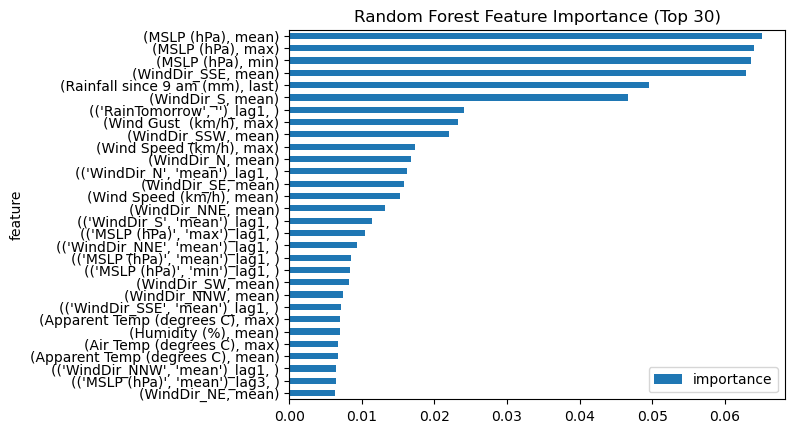

In [295]:
importance = pd.DataFrame({
    "feature": X_TSCV_Lag.columns,
    "importance": best_rf_TSCV_Lag.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 15))
importance.head(30).plot(kind='barh', x='feature', y='importance')
plt.title("Random Forest Feature Importance (Top 30)")
plt.gca().invert_yaxis()
plt.show()

### Lag Adjustment (Lag Window = lag1)

In [324]:
lag_daily_one = daily_data.copy()

for col in continuous_cols:
    for lag in range(1, 2):
        lag_daily_one[f"{col}_lag{lag}"] = lag_daily_one[col].shift(lag)

lag_daily_one = lag_daily_one.dropna()
lag_daily_one

,WindDir_CALM,WindDir_E,WindDir_ENE,WindDir_ESE,WindDir_N,WindDir_NE,WindDir_NNE,WindDir_NNW,WindDir_NW,WindDir_S,...,"('E (hPa)', 'max')_lag1","('E (hPa)', 'min')_lag1","('Dew Pt Temp (degrees C)', 'mean')_lag1","('Dew Pt Temp (degrees C)', 'max')_lag1","('Dew Pt Temp (degrees C)', 'min')_lag1","('Apparent Temp (degrees C)', 'mean')_lag1","('Apparent Temp (degrees C)', 'max')_lag1","('Apparent Temp (degrees C)', 'min')_lag1","('Rainfall since 9 am (mm)', 'last')_lag1","('RainTomorrow', '')_lag1"
,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,...,,,,,,,,,,
Datetime,,,,,,,,,,,,,,,,,,,,,
2011-01-02,0.00,0.000,0.000000,0.000000,0.000000,0.000000,0.000,0.000000,0.000000,0.632653,...,16.879444,11.846629,12.004651,14.900,9.6,0.000000,0.000,0.0,0.0,False
2011-01-03,0.00,0.000,0.000000,0.007692,0.000000,0.000000,0.000,0.000000,0.000000,0.446154,...,13.447486,8.833384,8.087755,11.400,5.2,0.000000,0.000,0.0,0.0,False
2011-01-04,0.00,0.000,0.000000,0.000000,0.000000,0.000000,0.000,0.007752,0.000000,0.255814,...,10.048411,8.068491,5.462308,7.100,3.9,0.000000,0.000,0.0,0.0,False
2011-01-05,0.00,0.000,0.000000,0.000000,0.000000,0.000000,0.000,0.000000,0.007752,0.418605,...,14.287514,9.351915,8.866667,12.400,6.2,0.000000,0.000,0.0,0.0,False
2011-01-06,0.00,0.008,0.016000,0.016000,0.136000,0.008000,0.032,0.056000,0.088000,0.152000,...,15.055950,11.836166,11.719380,13.200,9.7,0.000000,0.000,0.0,0.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-03-04,0.12,0.032,0.016000,0.016000,0.272000,0.024000,0.048,0.064000,0.072000,0.056000,...,20.601457,15.486953,16.234843,17.975,13.6,24.716339,30.350,19.8,0.0,True
2022-03-05,0.00,0.000,0.015038,0.000000,0.007519,0.022556,0.000,0.000000,0.007519,0.195489,...,24.820616,14.822663,16.648400,21.025,12.9,25.397400,31.925,18.7,3.8,True


In [297]:
model_df_TSCV_Lag_One = lag_daily_one.copy()

y_TSCV_Lag_One = model_df_TSCV_Lag_One['RainTomorrow'].astype(int)
X_TSCV_Lag_One = model_df_TSCV_Lag_One.drop(columns=['RainTomorrow'])

tscv = TimeSeriesSplit(n_splits=5)

rf_TSCV_Lag_One = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)

param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 3, 5],
    'max_features': ['sqrt', 'log2']
}

grid = GridSearchCV(
    estimator=rf_TSCV_Lag_One,
    param_grid=param_grid,
    cv=tscv,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_TSCV_Lag_One, y_TSCV_Lag_One)

best_rf_TSCV_Lag_One = grid.best_estimator_
print("Best params:", grid.best_params_)

Best params: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 200}


In [339]:
train_idx, test_idx = list(tscv.split(X_TSCV_Lag_One))[-1]

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test_lag1 = y.iloc[train_idx], y.iloc[test_idx]

best_rf_TSCV_Lag_One.fit(X_train, y_train)

y_pred_lag1 = best_rf_TSCV_Lag_One.predict(X_test)
y_prob_lag1 = best_rf_TSCV_Lag_One.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test_lag1, y_pred_lag1))
print("Precision:", precision_score(y_test_lag1, y_pred_lag1))
print("Recall:", recall_score(y_test_lag1, y_pred_lag1))
print("F1:", f1_score(y_test_lag1, y_pred_lag1))
print("ROC-AUC:", roc_auc_score(y_test_lag1, y_prob_lag1))

Accuracy: 0.6828908554572272
Precision: 0.4840764331210191
Recall: 0.7414634146341463
F1: 0.5857418111753372
ROC-AUC: 0.7474243283659052


### Lag Adjustment (Lag Window = lag1 of top 30 feature importance in lag3)

In [318]:
Lag_importance = pd.DataFrame(importance.head(30))
lag1_cols = [col[0] for col in Lag_importance['feature'] if col[0].endswith("lag1")]
lag1_cols

["('RainTomorrow', '')_lag1",
 "('WindDir_N', 'mean')_lag1",
 "('WindDir_S', 'mean')_lag1",
 "('MSLP (hPa)', 'max')_lag1",
 "('WindDir_NNE', 'mean')_lag1",
 "('MSLP (hPa)', 'mean')_lag1",
 "('MSLP (hPa)', 'min')_lag1",
 "('WindDir_SSE', 'mean')_lag1",
 "('WindDir_NNW', 'mean')_lag1"]

In [320]:
lag_daily_one_partial = daily_data.copy()

for col in continuous_cols:
    if f"{col}_lag1" in lag1_cols:
        lag_daily_one_partial[f"{col}_lag1"] = lag_daily_one_partial[col].shift(1)
        
lag_daily_one_partial = lag_daily_one_partial.dropna()
lag_daily_one_partial

,WindDir_CALM,WindDir_E,WindDir_ENE,WindDir_ESE,WindDir_N,WindDir_NE,WindDir_NNE,WindDir_NNW,WindDir_NW,WindDir_S,...,RainTomorrow,"('WindDir_N', 'mean')_lag1","('WindDir_NNE', 'mean')_lag1","('WindDir_NNW', 'mean')_lag1","('WindDir_S', 'mean')_lag1","('WindDir_SSE', 'mean')_lag1","('MSLP (hPa)', 'mean')_lag1","('MSLP (hPa)', 'max')_lag1","('MSLP (hPa)', 'min')_lag1","('RainTomorrow', '')_lag1"
,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,...,,,,,,,,,,
Datetime,,,,,,,,,,,,,,,,,,,,,
2011-01-02,0.00,0.000,0.000000,0.000000,0.000000,0.000000,0.000,0.000000,0.000000,0.632653,...,False,0.007752,0.007752,0.000000,0.418605,0.131783,1011.784496,1015.2,1007.2,False
2011-01-03,0.00,0.000,0.000000,0.007692,0.000000,0.000000,0.000,0.000000,0.000000,0.446154,...,False,0.000000,0.000000,0.000000,0.632653,0.275510,1016.310204,1017.6,1013.9,False
2011-01-04,0.00,0.000,0.000000,0.000000,0.000000,0.000000,0.000,0.007752,0.000000,0.255814,...,False,0.000000,0.000000,0.000000,0.446154,0.407692,1016.946154,1018.5,1015.6,False
2011-01-05,0.00,0.000,0.000000,0.000000,0.000000,0.000000,0.000,0.000000,0.007752,0.418605,...,False,0.000000,0.000000,0.007752,0.255814,0.341085,1012.396899,1016.3,1009.7,False
2011-01-06,0.00,0.008,0.016000,0.016000,0.136000,0.008000,0.032,0.056000,0.088000,0.152000,...,False,0.000000,0.000000,0.000000,0.418605,0.139535,1010.086047,1012.4,1008.2,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-03-04,0.12,0.032,0.016000,0.016000,0.272000,0.024000,0.048,0.064000,0.072000,0.056000,...,True,0.125984,0.039370,0.039370,0.125984,0.031496,1012.637008,1014.6,1011.0,True
2022-03-05,0.00,0.000,0.015038,0.000000,0.007519,0.022556,0.000,0.000000,0.007519,0.195489,...,False,0.272000,0.048000,0.064000,0.056000,0.000000,1009.955200,1013.0,1006.9,True


In [328]:
model_df_TSCV_Lag_One_Partial = lag_daily_one_partial.copy()

y_TSCV_Lag_One_Partial = model_df_TSCV_Lag_One_Partial['RainTomorrow'].astype(int)
X_TSCV_Lag_One_Partial = model_df_TSCV_Lag_One_Partial.drop(columns=['RainTomorrow'])

tscv = TimeSeriesSplit(n_splits=5)

rf_TSCV_Lag_One_Partial = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)

param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 3, 5],
    'max_features': ['sqrt', 'log2']
}

grid = GridSearchCV(
    estimator=rf_TSCV_Lag_One_Partial,
    param_grid=param_grid,
    cv=tscv,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_TSCV_Lag_One_Partial, y_TSCV_Lag_One_Partial)

best_rf_TSCV_Lag_One_Partial = grid.best_estimator_
print("Best params:", grid.best_params_)

Best params: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'n_estimators': 200}


In [338]:
train_idx, test_idx = list(tscv.split(X_TSCV_Lag_One_Partial))[-1]

X_train, X_test = X_TSCV_Lag_One_Partial.iloc[train_idx], X_TSCV_Lag_One_Partial.iloc[test_idx]
y_train, y_test_lag1_partial = y_TSCV_Lag_One_Partial.iloc[train_idx], y_TSCV_Lag_One_Partial.iloc[test_idx]

best_rf_TSCV_Lag_One_Partial.fit(X_train, y_train)

y_pred_lag1_partial = best_rf_TSCV_Lag_One_Partial.predict(X_test)
y_prob_lag1_partial = best_rf_TSCV_Lag_One_Partial.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test_lag1_partial, y_pred_lag1_partial))
print("Precision:", precision_score(y_test_lag1_partial, y_pred_lag1_partial))
print("Recall:", recall_score(y_test_lag1_partial, y_pred_lag1_partial))
print("F1:", f1_score(y_test_lag1_partial, y_pred_lag1_partial))
print("ROC-AUC:", roc_auc_score(y_test_lag1_partial, y_prob_lag1_partial))

Accuracy: 0.6902654867256637
Precision: 0.4921135646687697
Recall: 0.7609756097560976
F1: 0.5977011494252874
ROC-AUC: 0.7524570721394318


## Model Comparison

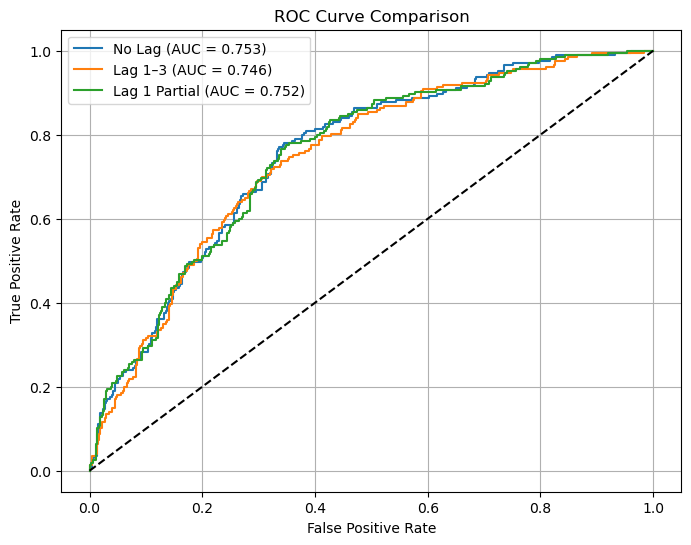

In [350]:
plt.figure(figsize=(8,6))

# No lag
fpr0, tpr0, _ = roc_curve(y_test_ori, y_prob_ori)
auc0 = auc(fpr0, tpr0)
plt.plot(fpr0, tpr0, label=f"No Lag (AUC = {auc0:.3f})")

# Lag 1–3
fpr1, tpr1, _ = roc_curve(y_test_lag3, y_prob_lag3)
auc1 = auc(fpr1, tpr1)
plt.plot(fpr1, tpr1, label=f"Lag 1–3 (AUC = {auc1:.3f})")

# Lag 1 partial
fpr2, tpr2, _ = roc_curve(y_test_lag1_partial, y_prob_lag1_partial)
auc2 = auc(fpr2, tpr2)
plt.plot(fpr2, tpr2, label=f"Lag 1 Partial (AUC = {auc2:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()

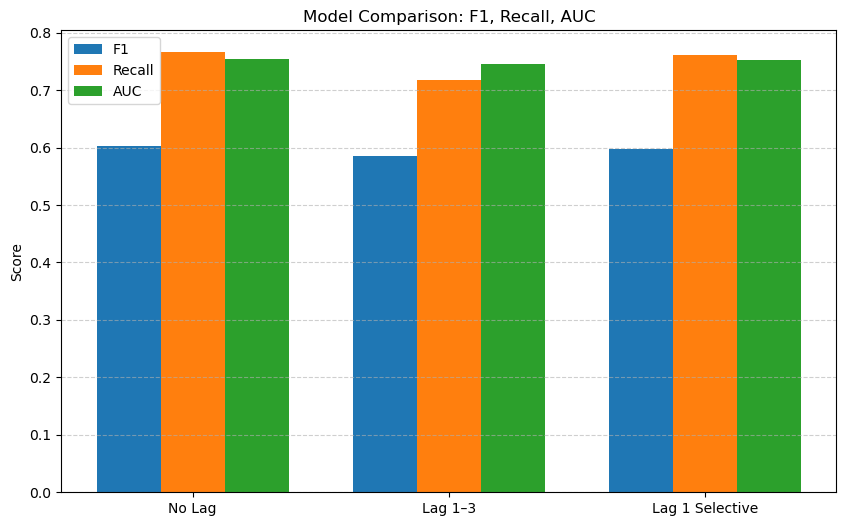

In [333]:
models = ["No Lag", "Lag 1–3", "Lag 1 Selective"]

f1_scores = [0.6027, 0.5850, 0.5977]
recalls =    [0.7659, 0.7184, 0.7610]
aucs =       [0.7534, 0.7463, 0.7525]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(10,6))
plt.bar(x - width, f1_scores, width, label="F1")
plt.bar(x, recalls, width, label="Recall")
plt.bar(x + width, aucs, width, label="AUC")

plt.xticks(x, models)
plt.ylabel("Score")
plt.title("Model Comparison: F1, Recall, AUC")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

# Final Model Evaluation

/var/folders/q0/1kjs8s8d6fn65050zv_j1x7c0000gn/T/ipykernel_15202/3959654372.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.scatter(rain_idx, y_test_ori[rain_idx],


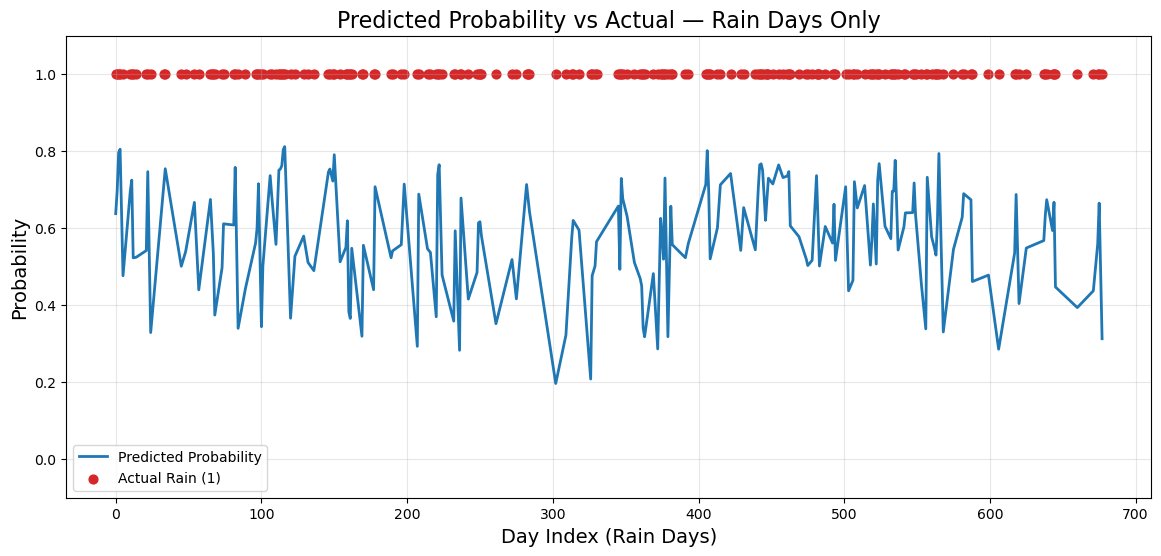

In [348]:
rain_idx = np.where(y_test_ori == 1)[0]

plt.figure(figsize=(14,6))

plt.plot(rain_idx, y_prob_ori[rain_idx], 
         color="#1f77b4", linewidth=2, label="Predicted Probability")

plt.scatter(rain_idx, y_test_ori[rain_idx], 
            color="#d62728", s=40, label="Actual Rain (1)")

plt.title("Predicted Probability vs Actual — Rain Days Only", fontsize=16)
plt.xlabel("Day Index (Rain Days)", fontsize=14)
plt.ylabel("Probability", fontsize=14)
plt.ylim(-0.1, 1.1)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

/var/folders/q0/1kjs8s8d6fn65050zv_j1x7c0000gn/T/ipykernel_15202/1663771574.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.scatter(norain_idx, y_test_ori[norain_idx],


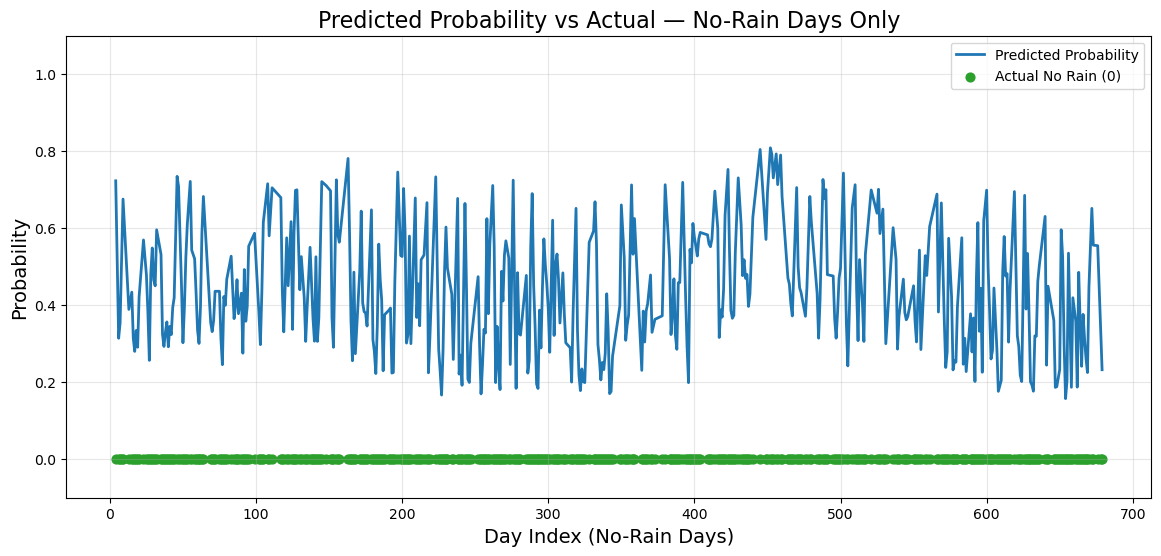

In [349]:
norain_idx = np.where(y_test_ori == 0)[0]

plt.figure(figsize=(14,6))

plt.plot(norain_idx, y_prob_ori[norain_idx], 
         color="#1f77b4", linewidth=2, label="Predicted Probability")

plt.scatter(norain_idx, y_test_ori[norain_idx], 
            color="#2ca02c", s=40, label="Actual No Rain (0)")

plt.title("Predicted Probability vs Actual — No-Rain Days Only", fontsize=16)
plt.xlabel("Day Index (No-Rain Days)", fontsize=14)
plt.ylabel("Probability", fontsize=14)
plt.ylim(-0.1, 1.1)
plt.grid(alpha=0.3)
plt.legend()
plt.show()